In [45]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.optimize import minimize_scalar

In [68]:
# Set magics
# use autoreload to only reload the user-written functions 
%load_ext autoreload
%autoreload 1

%aimport model 
%aimport nosharing
%aimport ekstra
# %aimport vareps
# %aimport baseline
# ^can be taken into usee when needed; they're in a separate folder, need to be taken out first

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [170]:
p1, p2, _ = model.solve_equilibrium(eps=0.4, s=1.9, gamma=0, mu=0.5, p1_init=0.5, p2_init=0.5, tol=1e-6, max_iter=500)
Theta = model.Theta_star(p1, p2, eps=0.4, s=1.9, gamma=0, mu=0.5)
print(p1, p2, Theta)

0.5987602045853916 0.5987602045868401 0.1202479590827768


In [171]:
eps = 0.4
s=1.9
t = eps*np.sqrt(2*s)-1/2*eps
print(t)

0.579743547584717



Parameter values

In [47]:
eps_grid = np.linspace(0.0, 0.5, 25)   # preference strength
s_grid   = np.linspace(0.001, 0.2, 25) # search cost (avoid 0 exactly)
prev_p1, prev_p2 = 0.5, 0.5

# Baseline model

In [48]:
mu = 1
gamma = 0
results_base = model.equilibrium_path_s_eps(eps_grid, s_grid, gamma, mu, prev_p1, prev_p2)
df = pd.DataFrame(results_base)
df["Theta"] = df["Theta"].clip(0, 1)

# Variable Epsilon

$\mu=0.75$ - variable epsilon in play.

In [125]:
mu = 0.5
gamma = 0
results_vareps = model.equilibrium_path_s_eps(eps_grid, s_grid, gamma, mu, prev_p1, prev_p2)
df_vareps = pd.DataFrame(results_vareps)
df_vareps["Theta"] = df_vareps["Theta"].clip(0, 1)

# Figures to compare baseline and variable epsilon
**Colorbar**


Baseline

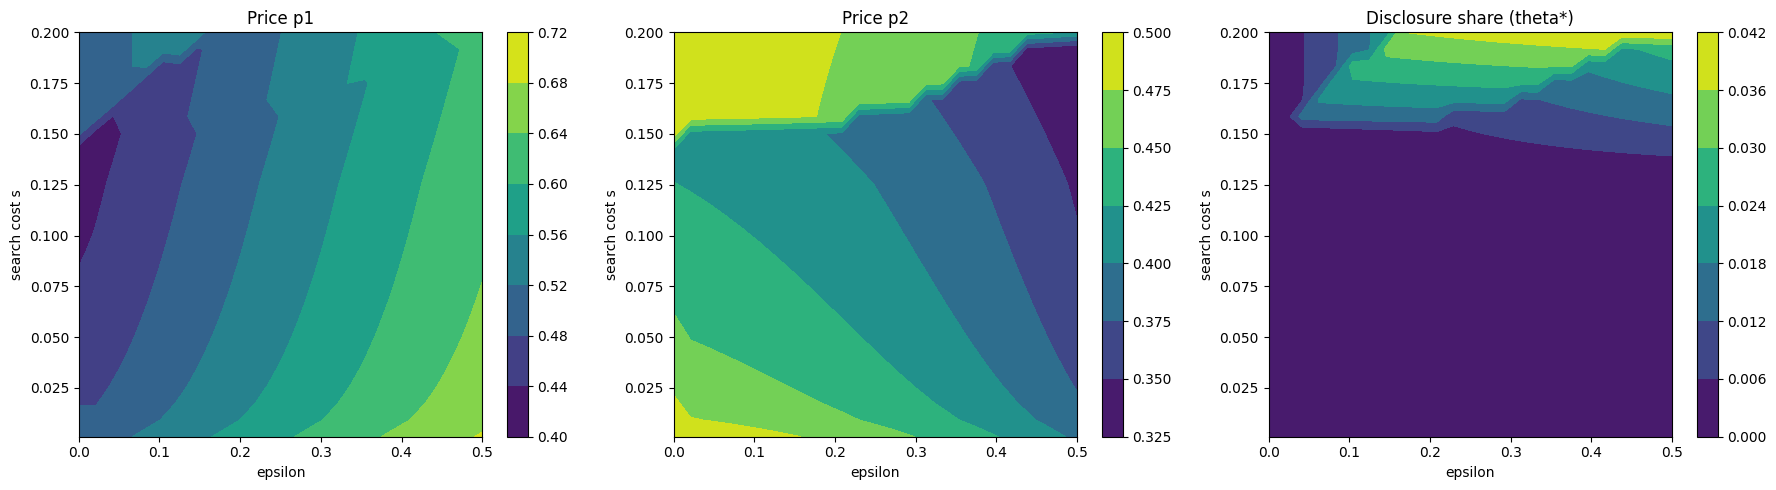

In [50]:
model.plot_colorblock(df, eps_grid, s_grid)

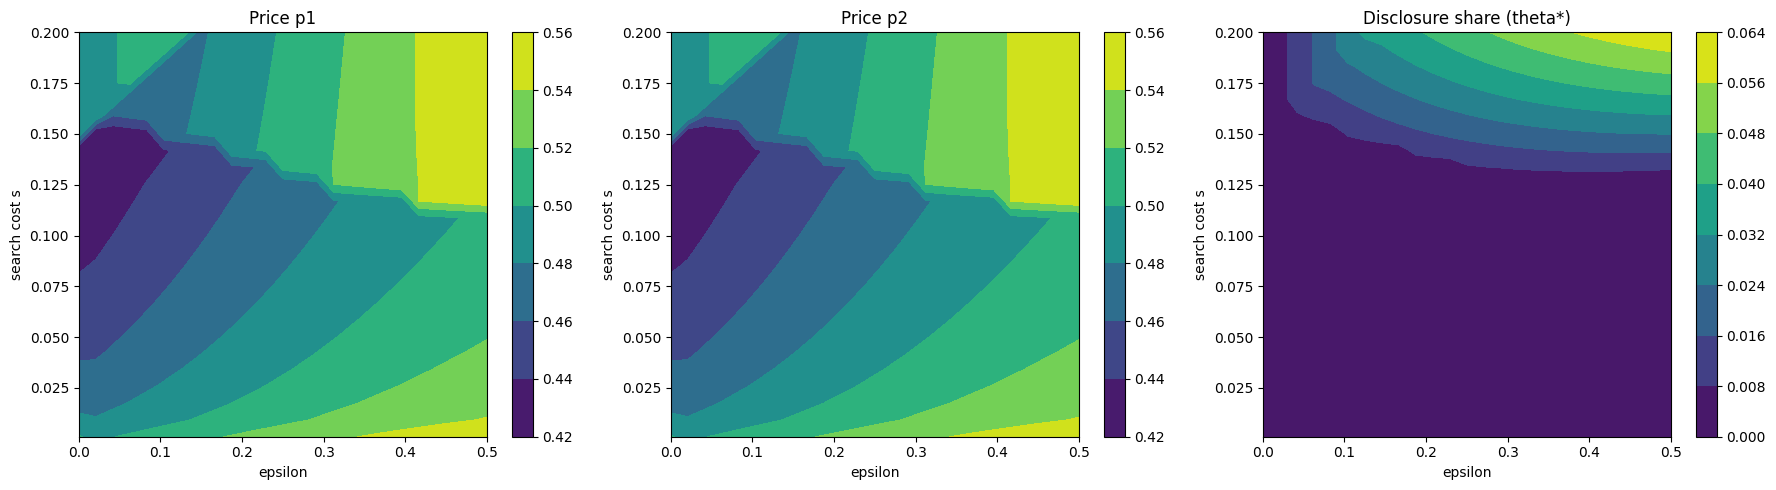

In [126]:
model.plot_colorblock(df_vareps, eps_grid, s_grid)

Variable epsilon

**Separate cases: functions of $\varepsilon$**

In [52]:
# Shared parameters
eps_grid = np.linspace(0.0, 0.5, 25)
s_values = [0.1, 0.15, 0.2]
p1_init, p2_init = 0.5, 0.5

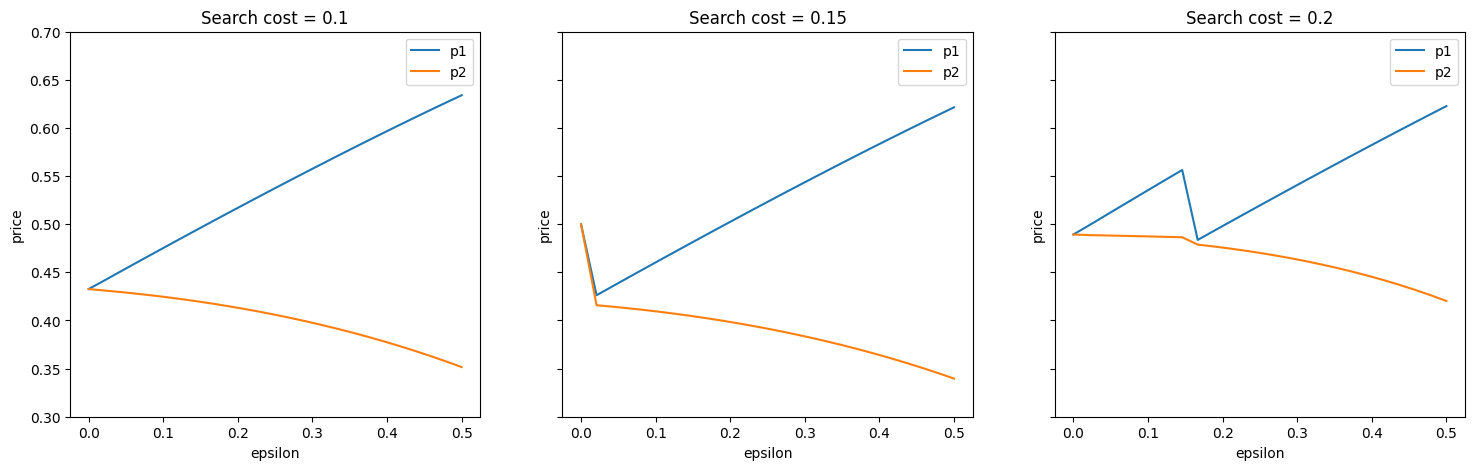

In [53]:
# baseline
gamma = 0
mu = 1
model.plot_price_curves(eps_grid, s_values, gamma, mu, p1_init, p2_init)

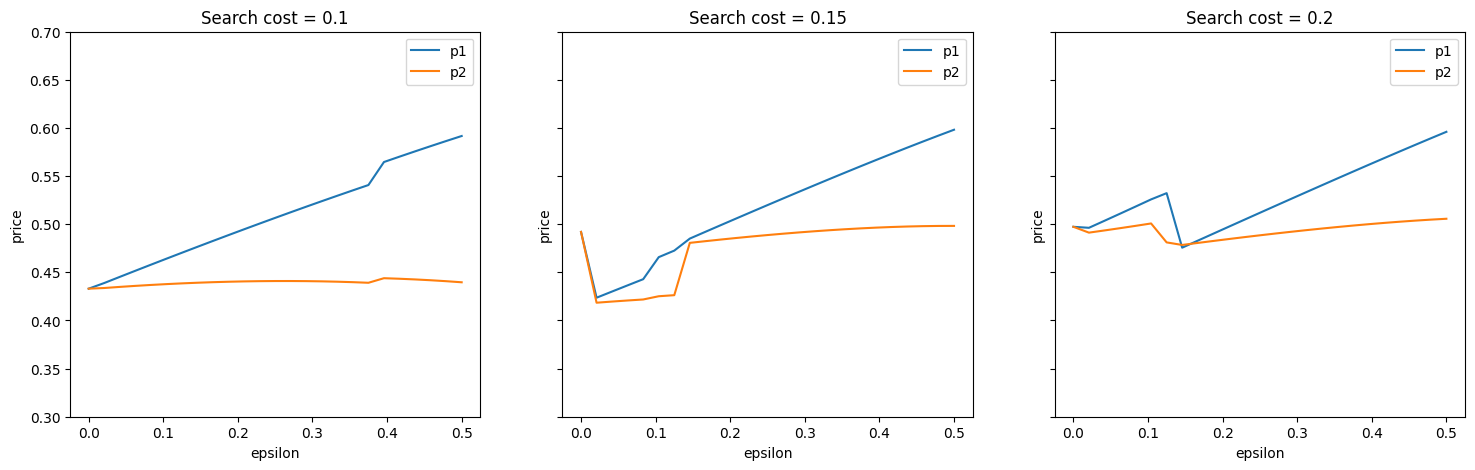

In [54]:
# variable epsilon
gamma = 0
mu = 0.75
model.plot_price_curves(eps_grid, s_values, gamma, mu, p1_init, p2_init)

# Baseline with naïvete

In [55]:
# Define parameter cases #
gamma_grid = np.linspace(0, 1, 50)

cases = [
    (0.1, 0.1),
    (0.2, 0.1),
    (0.2, 0.2),
    (0.2, 0.3)
]

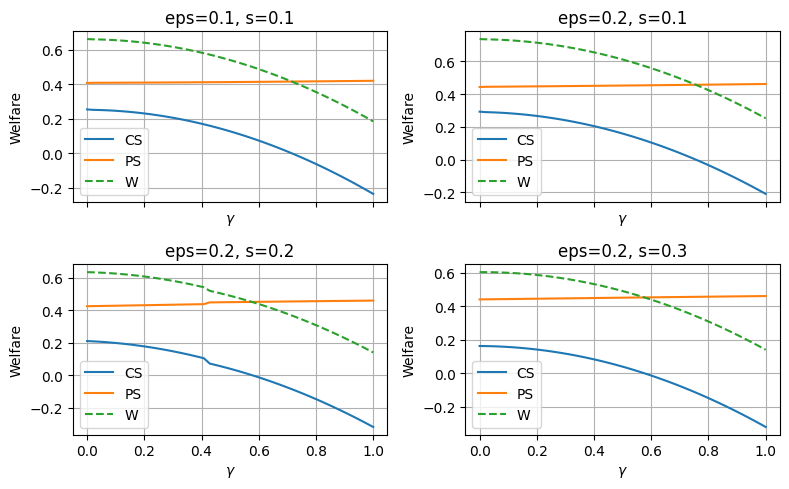

In [56]:
# baseline with naïvete
mu = 1
fig, axes = plt.subplots(2, 2, figsize=(8, 5), sharex=True)

for ax, (eps, s) in zip(axes.flatten(), cases):
    
    p1, p2, pi1, pi2, theta, CS, PS, W = model.compute_equilibrium_path(eps, s, gamma_grid, mu)
    ax.plot(gamma_grid, CS, label="CS")
    ax.plot(gamma_grid, PS, label="PS")
    ax.plot(gamma_grid, W, linestyle="--", label="W")
    
    ax.set_title(f"eps={eps}, s={s}")
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel("Welfare")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

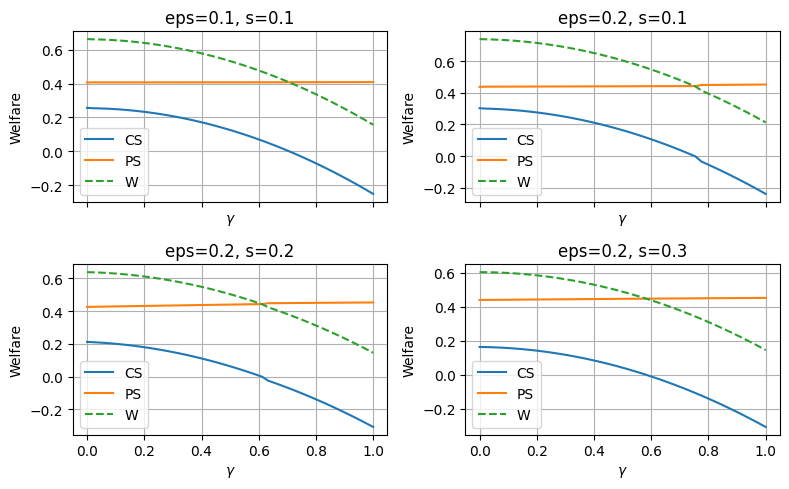

In [57]:
# variable epsilon with naïvete
mu = 0.75
fig, axes = plt.subplots(2, 2, figsize=(8, 5), sharex=True)

for ax, (eps, s) in zip(axes.flatten(), cases):
    
    p1, p2, pi1, pi2, theta, CS, PS, W = model.compute_equilibrium_path(eps, s, gamma_grid, mu)
    ax.plot(gamma_grid, CS, label="CS")
    ax.plot(gamma_grid, PS, label="PS")
    ax.plot(gamma_grid, W, linestyle="--", label="W")
    
    ax.set_title(f"eps={eps}, s={s}")
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel("Welfare")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

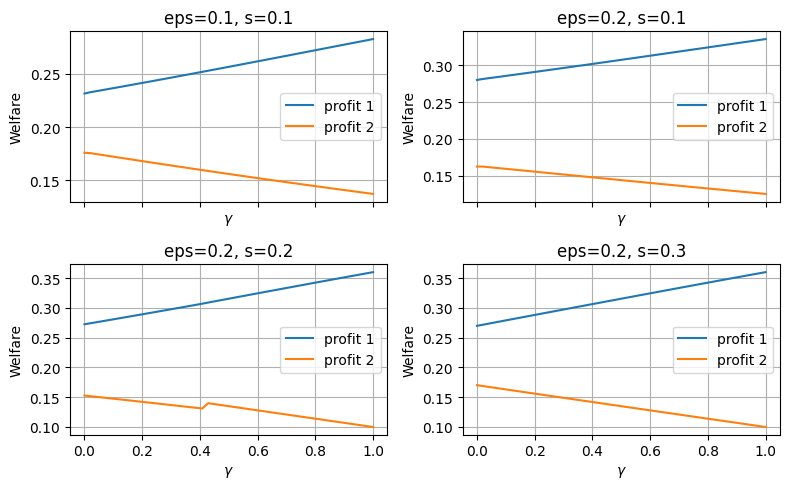

In [58]:
# baseline with naïvete
mu = 1
fig, axes = plt.subplots(2, 2, figsize=(8, 5), sharex=True)

for ax, (eps, s) in zip(axes.flatten(), cases):
    
    p1, p2, pi1, pi2, theta, CS, PS, W = model.compute_equilibrium_path(eps, s, gamma_grid, mu)
    ax.plot(gamma_grid, pi1, label="profit 1")
    ax.plot(gamma_grid, pi2, label="profit 2")
    
    ax.set_title(f"eps={eps}, s={s}")
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel("Welfare")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

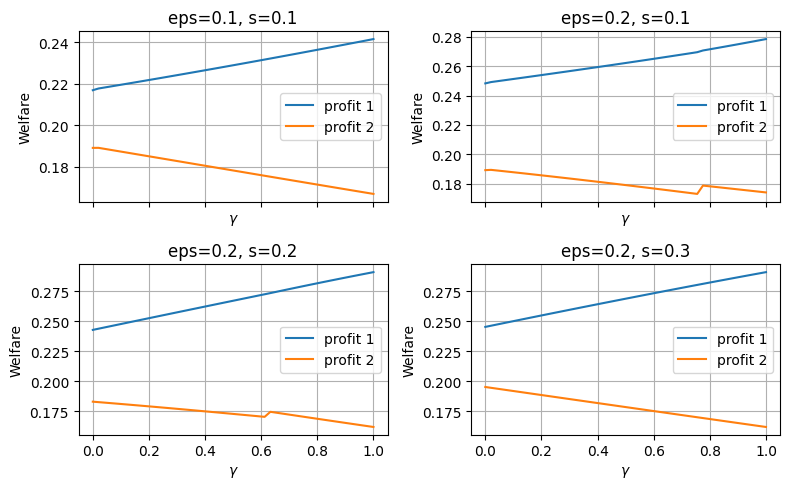

In [59]:
# variable epsilon with naïvete
mu = 0.75
fig, axes = plt.subplots(2, 2, figsize=(8, 5), sharex=True)

for ax, (eps, s) in zip(axes.flatten(), cases):
    
    p1, p2, pi1, pi2, theta, CS, PS, W = model.compute_equilibrium_path(eps, s, gamma_grid, mu)
    ax.plot(gamma_grid, pi1, label="profit 1")
    ax.plot(gamma_grid, pi2, label="profit 2")
    
    ax.set_title(f"eps={eps}, s={s}")
    ax.set_xlabel(r"$\gamma$")
    ax.set_ylabel("Welfare")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

In [60]:
eps_grid = np.linspace(0.0, 0.5, 25)   # preference strength
s_grid   = np.linspace(0.001, 0.2, 25) # search cost (avoid 0 exactly)
results_nosharing = []
p1_init, p2_init = 0.5, 0.5

In [166]:
eps, s = 0.2, 0.15
mu = 1
p1, p2, converged = nosharing.solve_equilibrium(eps, s, mu)
check = nosharing.check_interior(p1, p2, eps, s)

print(p1, p2)
print(check)

0.5044482625834389 0.40117373991249156
{'z_positive': True, 'support_ok': True, 'interior': True}


In [167]:
eps, s = 0.2, 0.15
p1, p2, converged = ekstra.solve_equilibrium(eps, s)
check = ekstra.check_interior(p1, p2, eps, s)

print(p1, p2)
print(check)

0.5044482625834389 0.40117373991249156
{'z_positive': True, 'support_ok': True, 'interior': True}


In [80]:
def compute_outcomes(eps, s, mu):

    results = {}

    # --- No sharing ---
    p1_ns, p2_ns, _ = nosharing.solve_equilibrium(eps, s, mu)
    pi1_ns = nosharing.profit1(p1_ns, p2_ns, eps, s, mu)
    pi2_ns = nosharing.profit2(p1_ns, p2_ns, eps, s, mu)

    results["No Sharing"] = {
        "p1": p1_ns,
        "p2": p2_ns,
        "pi1": pi1_ns,
        "pi2": pi2_ns,
        "CS": nosharing.consumer_surplus(p1_ns, p2_ns, eps, s, mu),
        "PS": pi1_ns + pi2_ns,
        "W": nosharing.total_welfare(p1_ns, p2_ns, eps, s, mu)
    }

    # --- Sharing, rational ---
    p1_r, p2_r, _ = model.solve_equilibrium(eps, s, gamma=0, mu=mu)
    pi1_r = model.profit1(p1_r, p2_r, eps, s, gamma=0, mu=mu)
    pi2_r = model.profit2(p1_r, p2_r, eps, s, gamma=0, mu=mu)

    results["Sharing (γ=0)"] = {
        "p1": p1_r,
        "p2": p2_r,
        "pi1": pi1_r,
        "pi2": pi2_r,
        "CS": model.consumer_surplus(p1_r, p2_r, eps, s, gamma=0, mu=mu),
        "PS": pi1_r + pi2_r,
        "W": model.total_welfare(p1_r, p2_r, eps, s, gamma=0, mu=mu)
    }

    # --- Sharing, naive ---
    p1_n, p2_n, _ = model.solve_equilibrium(eps, s, gamma=0.3, mu=mu)
    pi1_n = model.profit1(p1_n, p2_n, eps, s, gamma=0.3, mu=mu)
    pi2_n = model.profit2(p1_n, p2_n, eps, s, gamma=0.3, mu=mu)

    results["Sharing (γ=0.3)"] = {
        "p1": p1_n,
        "p2": p2_n,
        "pi1": pi1_n,
        "pi2": pi2_n,
        "CS": model.consumer_surplus(p1_n, p2_n, eps, s, gamma=0.3, mu=mu),
        "PS": pi1_n + pi2_n,
        "W": model.total_welfare(p1_n, p2_n, eps, s, gamma=0.3, mu=mu)
    }

    return pd.DataFrame(results).T

In [85]:
df_base = compute_outcomes(eps=0.5, s=0.19, mu=1)
print(df_base.round(3))

                    p1     p2    pi1    pi2     CS     PS      W
No Sharing       0.616  0.337  0.422  0.101  0.371  0.523  0.894
Sharing (γ=0)    0.611  0.328  0.421  0.098  0.378  0.519  0.897
Sharing (γ=0.3)  0.648  0.314  0.450  0.089  0.313  0.540  0.853


In [164]:
df_eps = compute_outcomes(eps=0.5, s=0.19, mu=0.75)
print(df_eps.round(3))

                    p1     p2    pi1    pi2     CS     PS      W
No Sharing       0.591  0.501  0.359  0.184  0.383  0.544  0.926
Sharing (γ=0)    0.597  0.504  0.362  0.184  0.380  0.547  0.926
Sharing (γ=0.3)  0.640  0.546  0.387  0.186  0.298  0.573  0.871


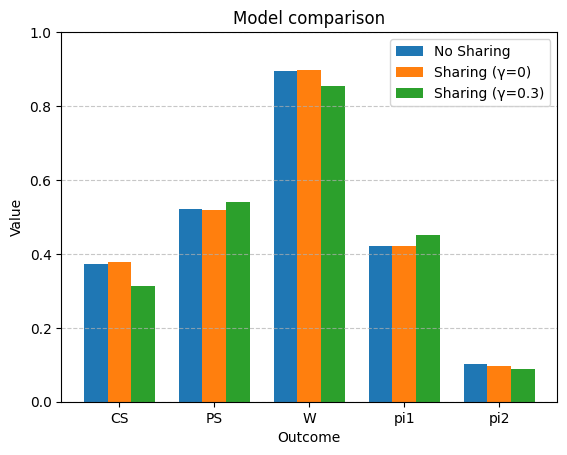

In [92]:
model.plot_welfare_comparison(df_base)

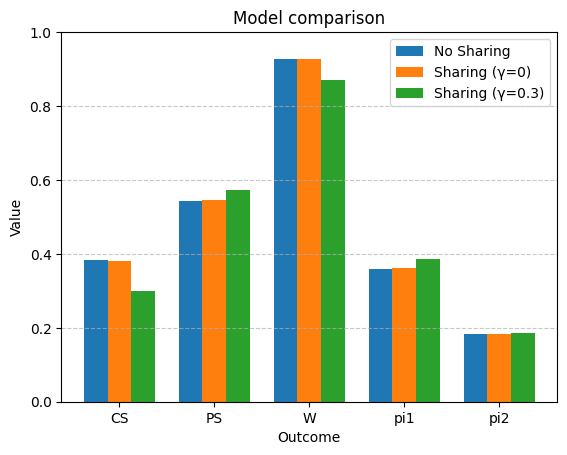

In [165]:
model.plot_welfare_comparison(df_eps)